# Heart-disease Notebook
Dataset: https://www.kaggle.com/datasets/alexteboul/heart-disease-health-indicators-dataset/discussion/284985

## Setup

In [55]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix


## Correlation

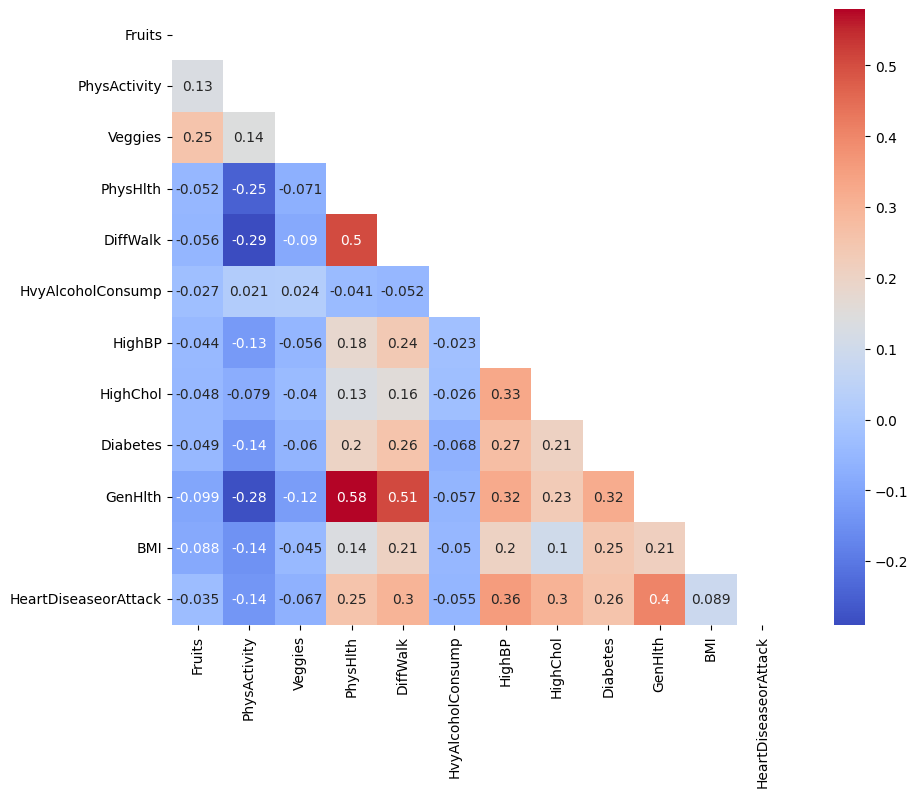

In [67]:
features = [
    'Fruits', 'PhysActivity', 'Veggies', 'PhysHlth', 'DiffWalk', 'HvyAlcoholConsump',
    'HighBP', 'HighChol', 'Diabetes', 'GenHlth', 'BMI'
]
target_column = "HeartDiseaseorAttack"

data_path = 'heart_disease_health_indicators_BRFSS2015.csv'
data = pd.read_csv(data_path)
data = data.dropna()

X = data[features]
y = data[target_column]

sampler = RandomUnderSampler(sampling_strategy=1)
X_s, y_s = sampler.fit_resample(X, y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_s)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled_df["HeartDiseaseorAttack"] = y_s

correlation_matrix = X_scaled_df.corr()

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', mask=mask, square=True)

plt.show()

## Machine Learning Models Evaluation

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

In [ ]:
data_path = 'heart_disease_health_indicators_BRFSS2015.csv'
data = pd.read_csv(data_path)
data = data.dropna()

features = [
    'Fruits', 'PhysActivity', 'Veggies', 'PhysHlth', 'DiffWalk', 'HvyAlcoholConsump',
    'HighBP', 'HighChol', 'Diabetes', 'GenHlth', 'BMI'
]
target_column = "HeartDiseaseorAttack"

X = data[features]
y = data[target_column]

sampler = RandomUnderSampler(sampling_strategy=1)
X_s, y_s = sampler.fit_resample(X, y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_s)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_s, test_size=0.2, random_state=42)


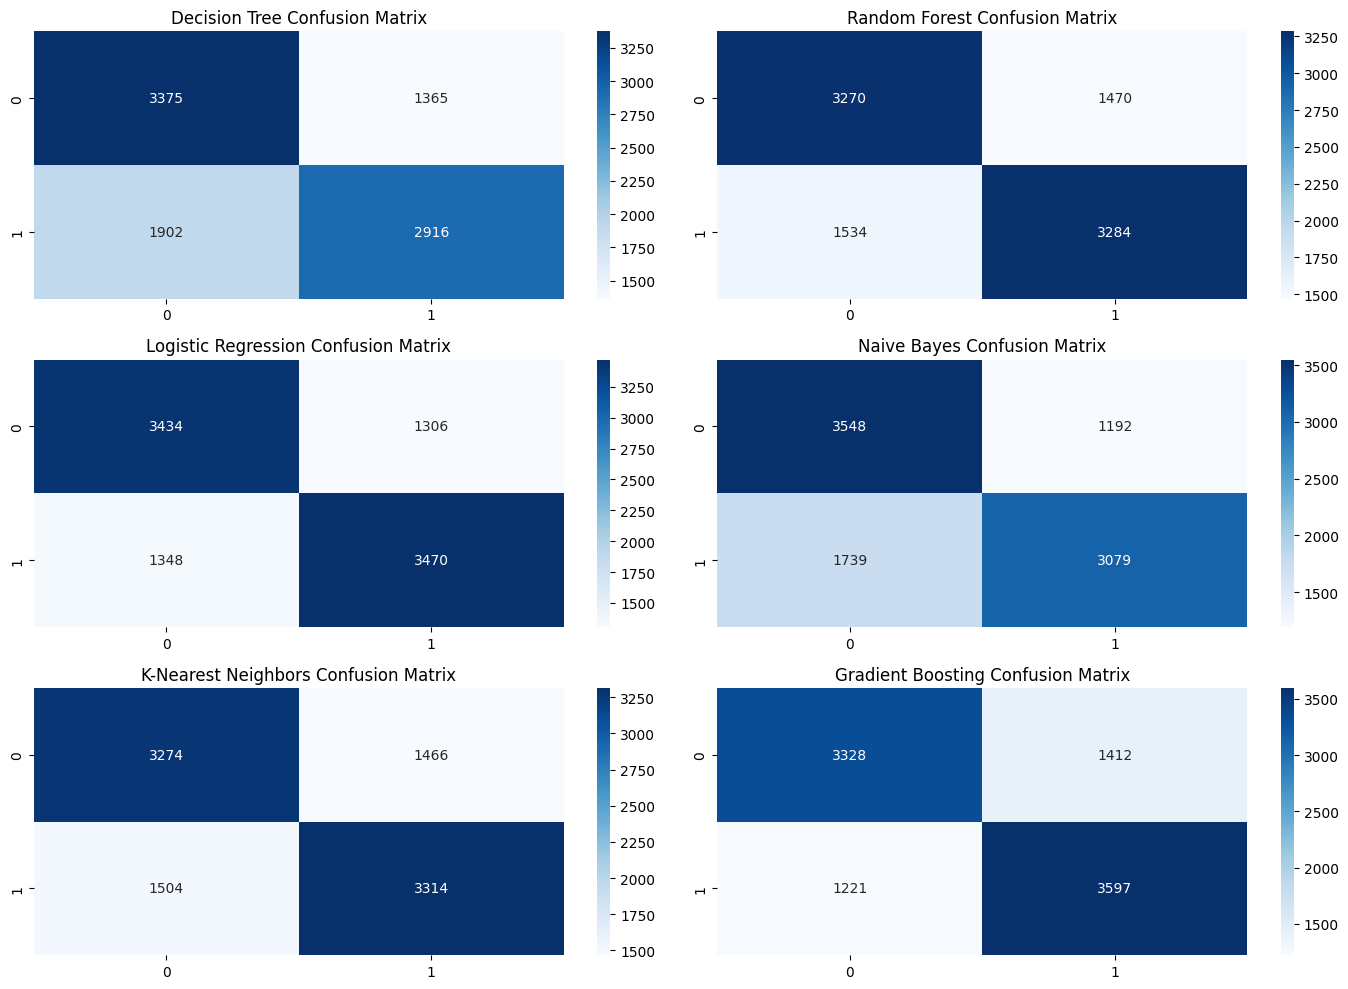

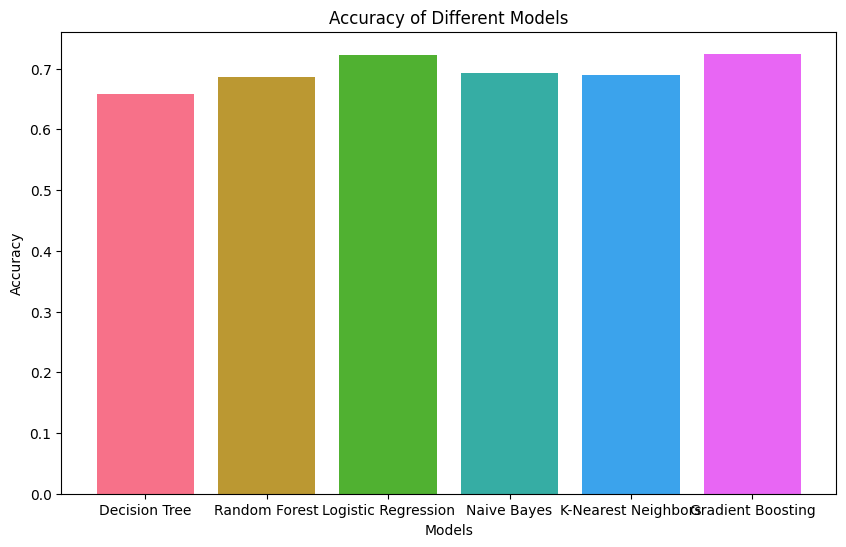


Decision Tree:

Metrics:
  Final Accuracy: 0.6582
  Final Precision: 0.6811
  Final Recall: 0.6052
  Final F1 Score: 0.6409
  Final ROC-AUC: 0.6586

Confusion Matrix:
  [3375 1365]
  [1902 2916]

Random Forest:

Metrics:
  Final Accuracy: 0.6857
  Final Precision: 0.6908
  Final Recall: 0.6816
  Final F1 Score: 0.6862
  Final ROC-AUC: 0.6857

Confusion Matrix:
  [3270 1470]
  [1534 3284]

Logistic Regression:

Metrics:
  Final Accuracy: 0.7223
  Final Precision: 0.7265
  Final Recall: 0.7202
  Final F1 Score: 0.7234
  Final ROC-AUC: 0.7223

Confusion Matrix:
  [3434 1306]
  [1348 3470]

Naive Bayes:

Metrics:
  Final Accuracy: 0.6933
  Final Precision: 0.7209
  Final Recall: 0.6391
  Final F1 Score: 0.6775
  Final ROC-AUC: 0.6938

Confusion Matrix:
  [3548 1192]
  [1739 3079]

K-Nearest Neighbors:

Metrics:
  Final Accuracy: 0.6893
  Final Precision: 0.6933
  Final Recall: 0.6878
  Final F1 Score: 0.6906
  Final ROC-AUC: 0.6893

Confusion Matrix:
  [3274 1466]
  [1504 3314]

Gradient 

In [ ]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=43),
    "Random Forest": RandomForestClassifier(random_state=43),
    "Logistic Regression": LogisticRegression(random_state=43),
    "Naive Bayes": GaussianNB(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=43)
}

results = {}
accuracy_scores = []

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    final_metrics = {
        'Final Accuracy': accuracy_score(y_test, y_pred),
        'Final Precision': precision_score(y_test, y_pred),
        'Final Recall': recall_score(y_test, y_pred),
        'Final F1 Score': f1_score(y_test, y_pred),
        'Final ROC-AUC': roc_auc_score(y_test, y_pred),
    }
    cm_final = confusion_matrix(y_test, y_pred)
    results[model_name] = {
        "metrics": final_metrics,
        "confusion_matrix": cm_final
    }
    accuracy_scores.append((model_name, final_metrics['Final Accuracy']))

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (model_name, result) in zip(axes, results.items()):
    sns.heatmap(result["confusion_matrix"], annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(f"{model_name} Confusion Matrix")

plt.tight_layout()
plt.show()

model_names, accuracies = zip(*accuracy_scores)
colors = sns.color_palette("husl", len(models))

print('\n')
plt.figure(figsize=(10, 6))
plt.bar(model_names, accuracies, color=colors)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Accuracy of Different Models")
plt.show()

for model_name, result in results.items():
    print(f"\n{model_name}:\n")
    print("Metrics:")
    for metric_name, metric_value in result["metrics"].items():
        print(f"  {metric_name}: {metric_value:.4f}")
    print("\nConfusion Matrix:")
    for row in result["confusion_matrix"]:
        print(f"  {row}")


In [ ]:
# Sample scenarios
unhealthy_individual = [0, 0, 0, 30, 1, 1, 1, 1, 1, 5, 40]
healthy_individual = [1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 22]
mixed_individual = [0, 1, 1, 15, 1, 0, 1, 1, 0, 3, 30]

# Standardizing the new data
unhealthy_scaled = scaler.transform([unhealthy_individual])
healthy_scaled = scaler.transform([healthy_individual])
mixed_scaled = scaler.transform([mixed_individual])

# Run predictions
predictions = {}

for model_name, model in models.items():
    # Predict class
    unhealthy_prediction = model.predict(unhealthy_scaled)[0]
    healthy_prediction = model.predict(healthy_scaled)[0]
    mixed_prediction = model.predict(mixed_scaled)[0]

    # Predict probabilities
    unhealthy_prob = model.predict_proba(unhealthy_scaled)[0][1]
    healthy_prob = model.predict_proba(healthy_scaled)[0][1]
    mixed_prob = model.predict_proba(mixed_scaled)[0][1]

    predictions[model_name] = {
        "Unhealthy Individual": {
            "Prediction": "Heart Disease" if unhealthy_prediction == 1 else "No Heart Disease",
            "Probability": unhealthy_prob
        },
        "Healthy Individual": {
            "Prediction": "Heart Disease" if healthy_prediction == 1 else "No Heart Disease",
            "Probability": healthy_prob
        },
        "Mixed Individual": {
            "Prediction": "Heart Disease" if mixed_prediction == 1 else "No Heart Disease",
            "Probability": mixed_prob
        }
    }

# Structured printout
for model_name, preds in predictions.items():
    print(f"\nModel: {model_name}")
    for individual, details in preds.items():
        prediction = details["Prediction"]
        probability = details["Probability"]
        print(f"  {individual}:\n    Prediction: {prediction}\n    Probability: {probability:.2f}")



Model: Decision Tree
  Unhealthy Individual:
    Prediction: Heart Disease
    Probability: 1.00
  Healthy Individual:
    Prediction: No Heart Disease
    Probability: 0.05
  Mixed Individual:
    Prediction: No Heart Disease
    Probability: 0.00

Model: Random Forest
  Unhealthy Individual:
    Prediction: Heart Disease
    Probability: 0.87
  Healthy Individual:
    Prediction: No Heart Disease
    Probability: 0.05
  Mixed Individual:
    Prediction: Heart Disease
    Probability: 0.53

Model: Logistic Regression
  Unhealthy Individual:
    Prediction: Heart Disease
    Probability: 0.87
  Healthy Individual:
    Prediction: No Heart Disease
    Probability: 0.11
  Mixed Individual:
    Prediction: Heart Disease
    Probability: 0.74

Model: Naive Bayes
  Unhealthy Individual:
    Prediction: Heart Disease
    Probability: 0.99
  Healthy Individual:
    Prediction: No Heart Disease
    Probability: 0.00
  Mixed Individual:
    Prediction: Heart Disease
    Probability: 0.96

Mode

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


<ipython-input-38-26bf5861fdab>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="Blues_d")


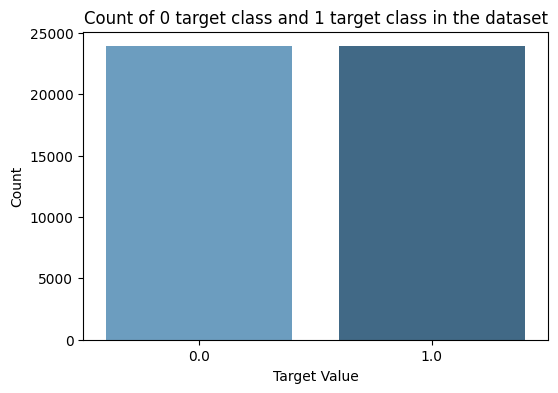

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

counts = y_s.value_counts()

# Plot the bar chart
plt.figure(figsize=(6, 4))
sns.barplot(x=counts.index, y=counts.values, palette="Blues_d")
plt.xlabel("Target Value")
plt.ylabel("Count")
plt.title("Count of 0 target class and 1 target class in the dataset")
plt.show()

## Deep Learning Models Evaluation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

### Feed-forward Neural Network

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 32)                384       
                                                                 
 dense_5 (Dense)             (None, 16)                528       
                                                                 
 dense_6 (Dense)             (None, 1)                 17        
                                                                 
Total params: 929 (3.63 KB)
Trainable params: 929 (3.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/20
956/956 [==============================] - 9s 7ms/step - loss: 0.5558 - accuracy: 0.7206 - val_loss: 0.5375 - val_accuracy: 0.7352
Epoch 2/20
956/956 [==============================] - 3s 3ms/step - loss: 0.5460 - accuracy: 0.7274 - val_loss: 0.5368 - val_accuracy: 0.7319
Epoc

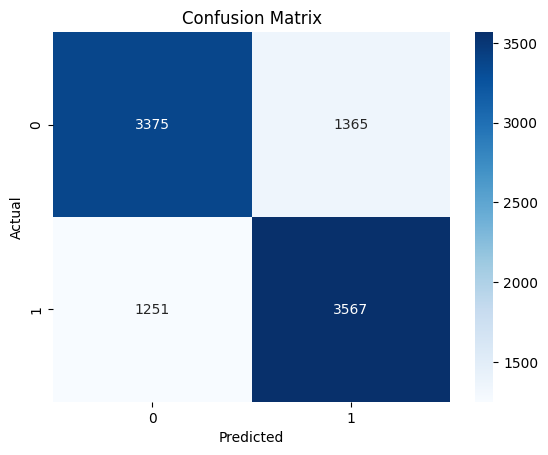

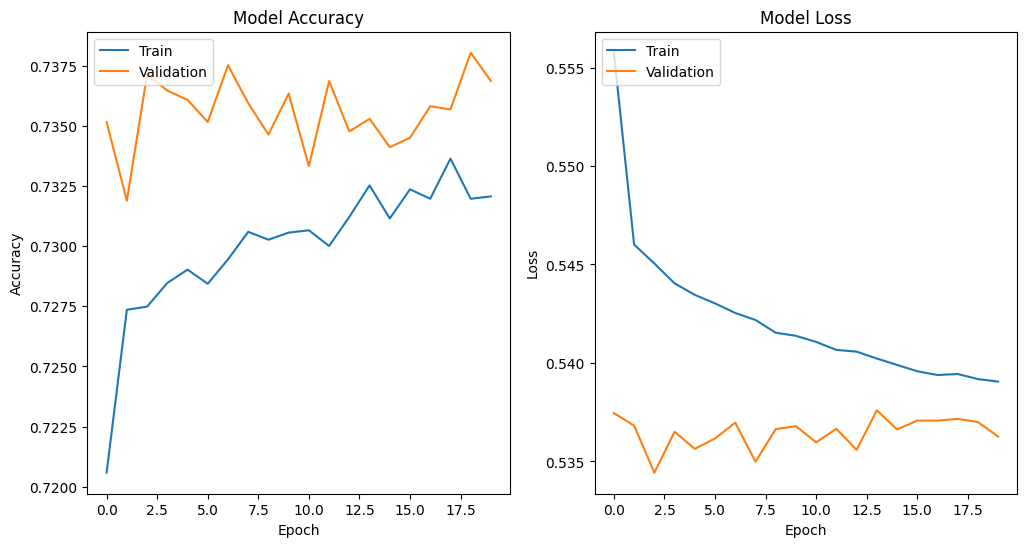

In [ ]:
# Build the neural network
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# Train the model
history = model.fit(X_train, y_train, validation_split=0.2, epochs=20, batch_size=32, verbose=1)

# Evaluate the model
y_pred = (model.predict(X_test) > 0.5).astype("int32")

evaluation_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1 Score': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_pred),
}

print("Evaluation Metrics:", evaluation_metrics)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

### CNN

Epoch 1/20
1195/1195 [==============================] - 6s 4ms/step - loss: 0.5560 - accuracy: 0.7216 - val_loss: 0.5590 - val_accuracy: 0.7198
Epoch 2/20
1195/1195 [==============================] - 4s 3ms/step - loss: 0.5489 - accuracy: 0.7262 - val_loss: 0.5557 - val_accuracy: 0.7168
Epoch 3/20
1195/1195 [==============================] - 4s 3ms/step - loss: 0.5479 - accuracy: 0.7271 - val_loss: 0.5523 - val_accuracy: 0.7262
Epoch 4/20
1195/1195 [==============================] - 5s 4ms/step - loss: 0.5472 - accuracy: 0.7270 - val_loss: 0.5528 - val_accuracy: 0.7196
Epoch 5/20
1195/1195 [==============================] - 4s 3ms/step - loss: 0.5467 - accuracy: 0.7278 - val_loss: 0.5516 - val_accuracy: 0.7249
Epoch 6/20
1195/1195 [==============================] - 4s 3ms/step - loss: 0.5464 - accuracy: 0.7274 - val_loss: 0.5511 - val_accuracy: 0.7250
Epoch 7/20
1195/1195 [==============================] - 5s 4ms/step - loss: 0.5461 - accuracy: 0.7290 - val_loss: 0.5542 - val_accuracy:

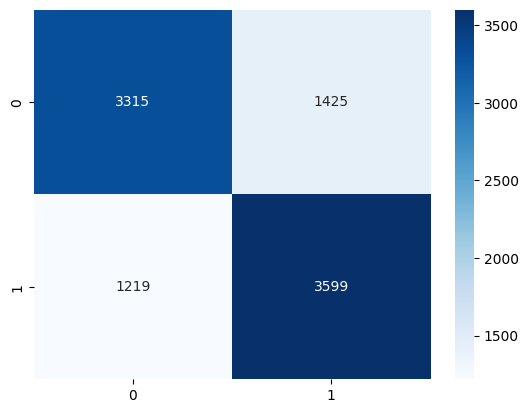

In [50]:
# Build the CNN model
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)),
    tf.keras.layers.MaxPooling1D(pool_size=2),
    tf.keras.layers.Conv1D(filters=64, kernel_size=3, activation='relu'),
    tf.keras.layers.MaxPooling1D(pool_size=2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

# Evaluate the model
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Final evaluation metrics
final_metrics = {
    'Final Accuracy': accuracy_score(y_test, y_pred),
    'Final Precision': precision_score(y_test, y_pred),
    'Final Recall': recall_score(y_test, y_pred),
    'Final F1 Score': f1_score(y_test, y_pred),
    'Final ROC-AUC': roc_auc_score(y_test, y_pred_prob)
}

print("Final Evaluation Metrics:", final_metrics)

# Final confusion matrix
cm_final = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_final, annot=True, fmt="d", cmap="Blues")
plt.show()

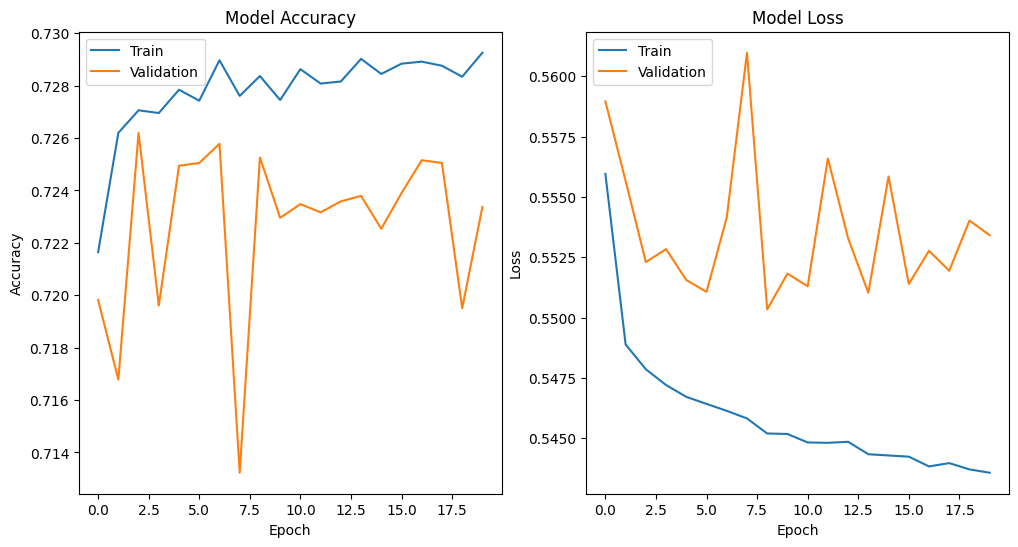

In [51]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()